    E-LIBRARY DATA INSIGHTS

Data loaded successfully!
Total Records: 5

       E-LIBRARY MANAGEMENT
1. Show Data
2. Data Analysis
3. Filter Data
4. Top Books Chart
5. Borrowing Trend
6. Genre Chart
7. Correlation Heatmap
8. Exit

========== LIBRARY DATA ==========
Transaction_ID User_ID        Book_Title       Genre Borrow_Date Return_Date  Borrow_Duration
          T001    U001     Python Basics Programming  2026-01-05  2026-01-15               10
          T002    U002      Data Science  Technology  2026-01-07  2026-01-20               13
          T003    U003     Atomic Habits   Self-Help  2026-01-10  2026-01-18                8
          T004    U004 Rich Dad Poor Dad     Finance  2026-01-12  2026-01-25               13
          T005    U005  Machine Learning Programming  2026-01-15  2026-01-30               15

       E-LIBRARY MANAGEMENT
1. Show Data
2. Data Analysis
3. Filter Data
4. Top Books Chart
5. Borrowing Trend
6. Genre Chart
7. Correlation Heatmap
8. Exit

========== 

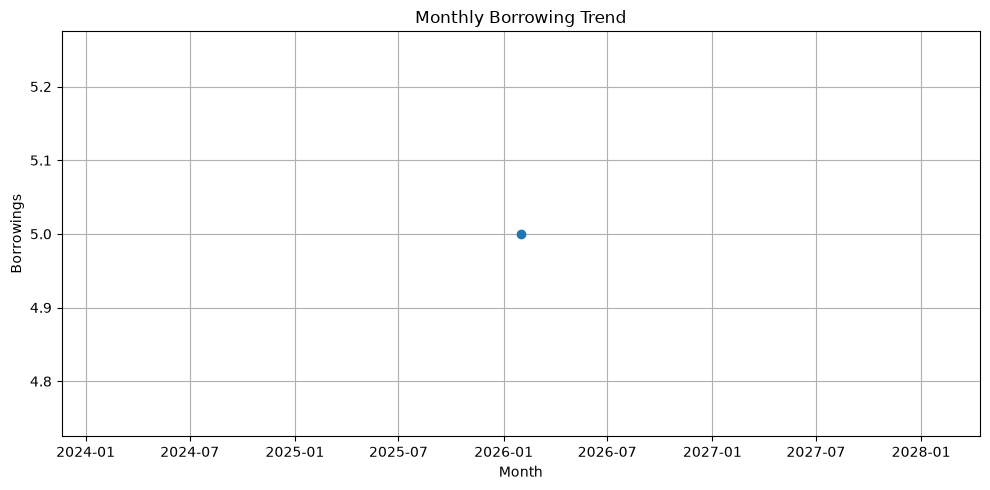


       E-LIBRARY MANAGEMENT
1. Show Data
2. Data Analysis
3. Filter Data
4. Top Books Chart
5. Borrowing Trend
6. Genre Chart
7. Correlation Heatmap
8. Exit


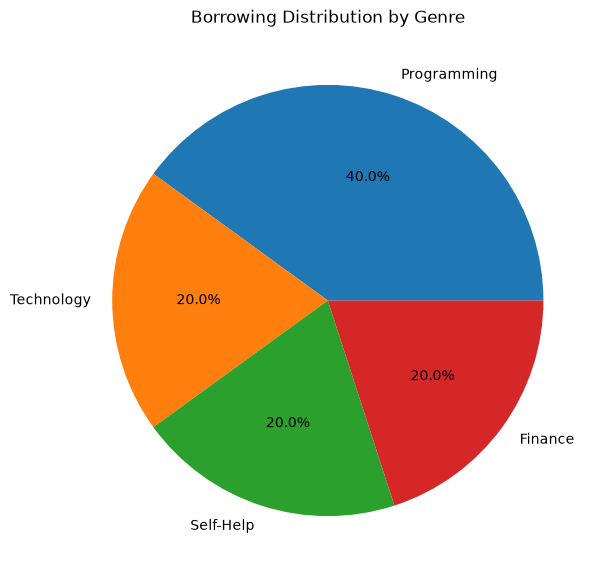


       E-LIBRARY MANAGEMENT
1. Show Data
2. Data Analysis
3. Filter Data
4. Top Books Chart
5. Borrowing Trend
6. Genre Chart
7. Correlation Heatmap
8. Exit


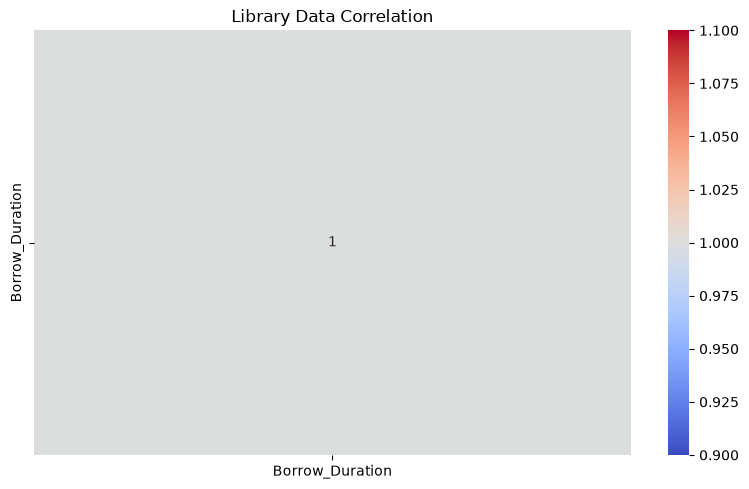


       E-LIBRARY MANAGEMENT
1. Show Data
2. Data Analysis
3. Filter Data
4. Top Books Chart
5. Borrowing Trend
6. Genre Chart
7. Correlation Heatmap
8. Exit

Program ended successfully!


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


class LibraryManager:

    def __init__(self, filename):
        self.filename = filename
        self.df = None

    # ==================================================
    # 1. LOAD DATA
    # ==================================================
    def load_data(self):

        if not os.path.exists(self.filename):
            print("File not found!")
            return False

        if not self.filename.endswith(".csv"):
            print("Only CSV files are allowed!")
            return False

        try:
            self.df = pd.read_csv(self.filename)

            if self.df.empty:
                print("CSV file is empty!")
                return False

            # Remove spaces from column names
            self.df.columns = self.df.columns.str.strip()

            # Convert dates
            date_columns = [
                "Borrow_Date",
                "Return_Date",
                "Date"
            ]

            for column in date_columns:

                if column in self.df.columns:
                    self.df[column] = pd.to_datetime(
                        self.df[column],
                        errors="coerce"
                    )

            # Calculate borrowing duration
            if (
                "Borrow_Date" in self.df.columns
                and "Return_Date" in self.df.columns
            ):

                self.df["Borrow_Duration"] = (
                    self.df["Return_Date"]
                    - self.df["Borrow_Date"]
                ).dt.days

            # Remove duplicates
            self.df.drop_duplicates(inplace=True)

            print("\nData loaded successfully!")
            print("Total Records:", len(self.df))

            return True

        except Exception as e:

            print("Error:", e)
            return False

    # ==================================================
    # 2. SHOW DATA
    # ==================================================
    def show_data(self):

        if self.df is None:
            print("Load data first!")
            return

        print("\n========== LIBRARY DATA ==========")

        print(self.df.to_string(index=False))

    # ==================================================
    # 3. DATA ANALYSIS
    # ==================================================
    def analysis(self):

        if self.df is None:
            print("Load data first!")
            return

        print("\n========== DATA ANALYSIS ==========")

        # Total transactions
        print(
            "Total Transactions:",
            len(self.df)
        )

        # Total users
        if "User_ID" in self.df.columns:

            print(
                "Total Users:",
                self.df["User_ID"].nunique()
            )

        # Total books
        if "Book_Title" in self.df.columns:

            print(
                "Total Books:",
                self.df["Book_Title"].nunique()
            )

            print("\nTop 5 Borrowed Books:")

            print(
                self.df["Book_Title"]
                .value_counts()
                .head(5)
            )

        # Genre
        if "Genre" in self.df.columns:

            print("\nGenre Count:")

            print(
                self.df["Genre"]
                .value_counts()
            )

        # NumPy statistics
        if "Borrow_Duration" in self.df.columns:

            values = self.df[
                "Borrow_Duration"
            ].dropna().values

            if len(values) > 0:

                print("\nBorrowing Duration Statistics")

                print(
                    "Average:",
                    round(np.mean(values), 2)
                )

                print(
                    "Median:",
                    round(np.median(values), 2)
                )

                print(
                    "Standard Deviation:",
                    round(np.std(values), 2)
                )

                print(
                    "Minimum:",
                    np.min(values)
                )

                print(
                    "Maximum:",
                    np.max(values)
                )

    # ==================================================
    # 4. FILTER DATA
    # ==================================================
    def filter_data(self):

        if self.df is None:
            print("Load data first!")
            return

        print("\n========== FILTER OPTIONS ==========")

        print("1. Genre")
        print("2. Borrow Duration")
        print("3. Borrow Date")
        print("4. Return Date")

        choice = input("Enter choice: ")

        # ------------------------------------------------
        # Genre
        # ------------------------------------------------
        if choice == "1":

            if "Genre" not in self.df.columns:
                print("Genre column not found!")
                return

            genre = input("Enter genre: ")

            result = self.df[
                self.df["Genre"]
                .astype(str)
                .str.lower()
                == genre.lower()
            ]

            print("\nFiltered Records:")
            print(result.to_string(index=False))

        # ------------------------------------------------
        # Borrow Duration
        # ------------------------------------------------
        elif choice == "2":

            if "Borrow_Duration" not in self.df.columns:
                print("Borrow_Duration column not found!")
                return

            try:

                days = int(
                    input("Minimum borrowing days: ")
                )

                result = self.df[
                    self.df["Borrow_Duration"] >= days
                ]

                print("\nFiltered Records:")
                print(result.to_string(index=False))

            except ValueError:

                print("Enter a valid number!")

        # ------------------------------------------------
        # Borrow Date
        # ------------------------------------------------
        elif choice == "3":

            if "Borrow_Date" not in self.df.columns:
                print("Borrow_Date column not found!")
                return

            try:

                start = pd.to_datetime(
                    input("Start date (YYYY-MM-DD): ")
                )

                end = pd.to_datetime(
                    input("End date (YYYY-MM-DD): ")
                )

                result = self.df[
                    (self.df["Borrow_Date"] >= start)
                    &
                    (self.df["Borrow_Date"] <= end)
                ]

                print("\nFiltered Records:")
                print(result.to_string(index=False))

            except ValueError:

                print("Invalid date!")

        # ------------------------------------------------
        # Return Date
        # ------------------------------------------------
        elif choice == "4":

            if "Return_Date" not in self.df.columns:
                print("Return_Date column not found!")
                return

            try:

                start = pd.to_datetime(
                    input("Start return date (YYYY-MM-DD): ")
                )

                end = pd.to_datetime(
                    input("End return date (YYYY-MM-DD): ")
                )

                result = self.df[
                    (self.df["Return_Date"] >= start)
                    &
                    (self.df["Return_Date"] <= end)
                ]

                print("\nFiltered Records:")
                print(result.to_string(index=False))

            except ValueError:

                print("Invalid date!")

        else:

            print("Invalid choice!")

    # ==================================================
    # 5. BAR CHART
    # ==================================================
    def book_chart(self):

        if self.df is None:
            print("Load data first!")
            return

        if "Book_Title" not in self.df.columns:
            print("Book_Title column not found!")
            return

        data = (
            self.df["Book_Title"]
            .value_counts()
            .head(5)
        )

        plt.figure(figsize=(9, 5))

        plt.bar(
            data.index,
            data.values
        )

        plt.title("Top 5 Most Borrowed Books")
        plt.xlabel("Book")
        plt.ylabel("Borrowings")

        plt.xticks(rotation=30)

        plt.tight_layout()
        plt.show()

    # ==================================================
    # 6. LINE CHART
    # ==================================================
    def trend_chart(self):

        if self.df is None:
            print("Load data first!")
            return

        if "Borrow_Date" not in self.df.columns:
            print("Borrow_Date column not found!")
            return

        monthly = (
            self.df
            .set_index("Borrow_Date")
            .resample("ME")
            .size()
        )

        plt.figure(figsize=(10, 5))

        plt.plot(
            monthly.index,
            monthly.values,
            marker="o"
        )

        plt.title("Monthly Borrowing Trend")
        plt.xlabel("Month")
        plt.ylabel("Borrowings")

        plt.grid(True)

        plt.tight_layout()
        plt.show()

    # ==================================================
    # 7. PIE CHART
    # ==================================================
    def genre_chart(self):

        if self.df is None:
            print("Load data first!")
            return

        if "Genre" not in self.df.columns:
            print("Genre column not found!")
            return

        data = self.df["Genre"].value_counts()

        plt.figure(figsize=(7, 7))

        plt.pie(
            data.values,
            labels=data.index,
            autopct="%1.1f%%"
        )

        plt.title("Borrowing Distribution by Genre")

        plt.show()

    # ==================================================
    # 8. HEATMAP
    # ==================================================
    def heatmap(self):

        if self.df is None:
            print("Load data first!")
            return

        numeric = self.df.select_dtypes(
            include=np.number
        )

        if numeric.empty:
            print("No numeric data available!")
            return

        plt.figure(figsize=(8, 5))

        sns.heatmap(
            numeric.corr(),
            annot=True,
            cmap="coolwarm"
        )

        plt.title("Library Data Correlation")

        plt.tight_layout()
        plt.show()

    # ==================================================
    # 9. MENU
    # ==================================================
    def menu(self):

        if not self.load_data():
            return

        while True:

            print("\n====================================")
            print("       E-LIBRARY MANAGEMENT")
            print("====================================")

            print("1. Show Data")
            print("2. Data Analysis")
            print("3. Filter Data")
            print("4. Top Books Chart")
            print("5. Borrowing Trend")
            print("6. Genre Chart")
            print("7. Correlation Heatmap")
            print("8. Exit")

            choice = input(
                "\nEnter your choice: "
            )

            if choice == "1":
                self.show_data()

            elif choice == "2":
                self.analysis()

            elif choice == "3":
                self.filter_data()

            elif choice == "4":
                self.book_chart()

            elif choice == "5":
                self.trend_chart()

            elif choice == "6":
                self.genre_chart()

            elif choice == "7":
                self.heatmap()

            elif choice == "8":

                print(
                    "\nProgram ended successfully!"
                )

                break

            else:

                print(
                    "Invalid choice!"
                )


# ======================================================
# PROGRAM START
# ======================================================

if __name__ == "__main__":

    print("====================================")
    print("    E-LIBRARY DATA INSIGHTS")
    print("====================================")

    filename = input(
        "Enter CSV file name: "
    )

    library = LibraryManager(filename)

    library.menu()